In [1]:
!git clone https://github.com/quark28/miniml.git
%cd miniml

Cloning into 'miniml'...
remote: Enumerating objects: 104, done.
remote: Counting objects: 100% (104/104), done.
remote: Compressing objects: 100% (76/76), done.
remote: Total 104 (delta 45), reused 83 (delta 24), pack-reused 0 (from 0)
Receiving objects: 100% (104/104), 767.00 KiB | 17.04 MiB/s, done.
Resolving deltas: 100% (45/45), done.
/content/miniml


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, normalize
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

from scaler import Scaler

In [3]:
np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)

In [4]:
diabetes = load_diabetes()
X = diabetes.data
feature_names = diabetes.feature_names

X_train, X_test = train_test_split(X, test_size=0.3, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (309, 10), Test: (133, 10)


In [5]:
my_scaler = Scaler()
my_scaler.fit(X_train, type='min_max', axis=0)
my_train_scaled = my_scaler.transform(X_train)
my_test_scaled = my_scaler.transform(X_test)

sk_scaler = MinMaxScaler()
sk_train_scaled = sk_scaler.fit_transform(X_train)
sk_test_scaled = sk_scaler.transform(X_test)

diff_train = np.max(np.abs(my_train_scaled - sk_train_scaled))
diff_test = np.max(np.abs(my_test_scaled - sk_test_scaled))

print(f"min_max — расхождение на train: {diff_train:.2e}")
print(f"min_max — расхождение на test:  {diff_test:.2e}")

min_max — расхождение на train: 2.22e-16
min_max — расхождение на test:  1.11e-16


In [6]:
outside_range = (my_test_scaled < 0) | (my_test_scaled > 1)
n_outside = outside_range.sum()
print(f"Значений в test вне диапазона [0,1] после min_max: {n_outside} из {my_test_scaled.size}")

Значений в test вне диапазона [0,1] после min_max: 4 из 1330


In [7]:
scaler_configs = [
    ('min_max', MinMaxScaler()),
    ('z_norm', StandardScaler()),
    ('robust', RobustScaler()),
]

results = []
for my_type, sk_model in scaler_configs:
    my_s = Scaler()
    my_s.fit(X_train, type=my_type, axis=0)
    my_tr = my_s.transform(X_train)
    my_te = my_s.transform(X_test)

    sk_tr = sk_model.fit_transform(X_train)
    sk_te = sk_model.transform(X_test)

    diff_tr = np.max(np.abs(my_tr - sk_tr))
    diff_te = np.max(np.abs(my_te - sk_te))

    results.append((my_type, diff_tr, diff_te))

df = pd.DataFrame(results, columns=['scaler', 'max_diff_train', 'max_diff_test'])
print(df.to_string(index=False))

 scaler  max_diff_train  max_diff_test
min_max    2.220446e-16   1.110223e-16
 z_norm    0.000000e+00   0.000000e+00
 robust    0.000000e+00   0.000000e+00


In [8]:
my_norm = Scaler()
my_norm.fit(X_train, type='norm', axis=0)
my_norm_train = my_norm.transform(X_train)
my_norm_test = my_norm.transform(X_test)  # использует норму, посчитанную на train

sk_norm_train = normalize(X_train, axis=0)
# для sklearn.normalize нет метода transform с сохранённой статистикой (это stateless-функция),
# поэтому применяем ту же норму train вручную для честного сравнения
train_norms = np.linalg.norm(X_train, axis=0, keepdims=True)
train_norms = np.where(train_norms == 0, 1, train_norms)
sk_norm_test_manual = X_test / train_norms

diff_norm_train = np.max(np.abs(my_norm_train - sk_norm_train))
diff_norm_test = np.max(np.abs(my_norm_test - sk_norm_test_manual))
print(f"norm — расхождение на train: {diff_norm_train:.2e}")
print(f"norm — расхождение на test (с нормой train):  {diff_norm_test:.2e}")

norm — расхождение на train: 0.00e+00
norm — расхождение на test (с нормой train):  0.00e+00


In [9]:
my_s2 = Scaler()
combo_result = my_s2.fit_transform(X_train, type='z_norm', axis=0)

my_s3 = Scaler()
my_s3.fit(X_train, type='z_norm', axis=0)
separate_result = my_s3.transform(X_train, use_fit_stats=True)

diff_combo = np.max(np.abs(combo_result - separate_result))
print(f"fit_transform vs fit()+transform(): расхождение = {diff_combo:.2e} (ожидается 0)")

fit_transform vs fit()+transform(): расхождение = 0.00e+00 (ожидается 0)


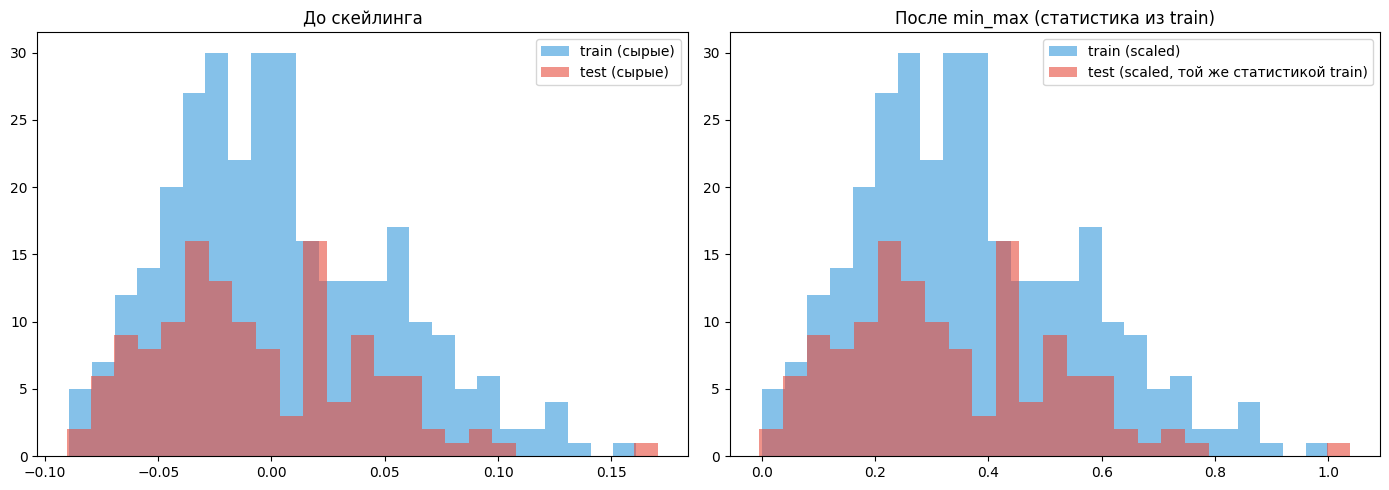

In [10]:
feature_idx = 2  # bmi

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(X_train[:, feature_idx], bins=25, alpha=0.6, label='train (сырые)', color='#3498db')
axes[0].hist(X_test[:, feature_idx], bins=25, alpha=0.6, label='test (сырые)', color='#e74c3c')
axes[0].set_title('До скейлинга')
axes[0].legend()

axes[1].hist(my_train_scaled[:, feature_idx], bins=25, alpha=0.6, label='train (scaled)', color='#3498db')
axes[1].hist(my_test_scaled[:, feature_idx], bins=25, alpha=0.6, label='test (scaled, той же статистикой train)', color='#e74c3c')
axes[1].set_title('После min_max (статистика из train)')
axes[1].legend()

plt.tight_layout()
plt.savefig('train_test_scaling.png', dpi=100)
plt.show()

In [12]:
try:
    fresh_scaler = Scaler()
    fresh_scaler.transform(X_test)
    print("ОШИБКА ТЕСТА: transform() без fit() не упал — так быть не должно")
except AttributeError as e:
    print(f"OK: transform() без fit() корректно падает с AttributeError: {e}")

print(df.to_string(index=False))
print()

OK: transform() без fit() корректно падает с AttributeError: 'Scaler' object has no attribute 'method'
 scaler  max_diff_train  max_diff_test
min_max    2.220446e-16   1.110223e-16
 z_norm    0.000000e+00   0.000000e+00
 robust    0.000000e+00   0.000000e+00

